# 03. Documento de trabajo para verificar la hipótesis #01

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

clean_data_df = pd.read_csv("..\\data\\CLEAN_Students_Social_Media_Addiction.csv")
clean_data_df.index = clean_data_df["Student_ID"]

clean_data_df = clean_data_df.drop(columns=["Unnamed: 0"]) # Eliminamos la columna que había quedado guardada como índice
clean_data_df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
Student_ID,,,,,,,,,,,,,
3,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
4,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
5,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
6,6,19,Female,Undergraduate,Australia,7.2,Instagram,Yes,4.5,4,Complicated,5,9
7,7,23,Male,Graduate,Germany,1.5,LinkedIn,No,8.0,9,Single,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,699,19,Female,Undergraduate,Canada,5.7,Instagram,Yes,6.6,6,Single,3,7
700,700,22,Male,Graduate,UK,6.2,Twitter,Yes,6.3,5,Single,4,8
701,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5


In [3]:
clean_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 503 entries, 3 to 705
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    503 non-null    int64  
 1   Age                           503 non-null    int64  
 2   Gender                        503 non-null    object 
 3   Academic_Level                503 non-null    object 
 4   Country                       503 non-null    object 
 5   Avg_Daily_Usage_Hours         503 non-null    float64
 6   Most_Used_Platform            503 non-null    object 
 7   Affects_Academic_Performance  503 non-null    object 
 8   Sleep_Hours_Per_Night         503 non-null    float64
 9   Mental_Health_Score           503 non-null    int64  
 10  Relationship_Status           503 non-null    object 
 11  Conflicts_Over_Social_Media   503 non-null    int64  
 12  Addicted_Score                503 non-null    int64  
dtypes: float64

### 3.1 Hipótesis: Instagram y Tik Tok son las redes sociales donde, de media, más horas dedican los participantes de la encuesta

In [14]:
# Al revisar detenidamente la explicación del campo "Avg_Daily_Usage_Hours", he observado que no es posible 
# verificar la hipótesis cuantitavamente , puesto que el campo mide el total de horas dedicadas en TODAS las 
# redes sociales:
# "Avg_Daily_Usage_Hours: The average number of hours per day the student spends on social media platforms, calculated from self-reported weekday and weekend usage estimates."

# Como workaround, estableceremos 2 sub-hipótesis que nos permitan dar por probada nuestra hipótesis principal:

# Sub-hipótesis 1: A nivel de conteo, Instagram y Tik Tok son las redes sociales que más veces han entrado en la categoría de "Most_Used_Platform" de entre todas las del dataset

most_used_platform_count = clean_data_df.groupby("Most_Used_Platform")["Student_ID"].count().reset_index()
most_used_platform_count.columns = ["Most_Used_Platform", "Count"]
most_used_platform_count = most_used_platform_count.sort_values(by="Count", ascending=False)


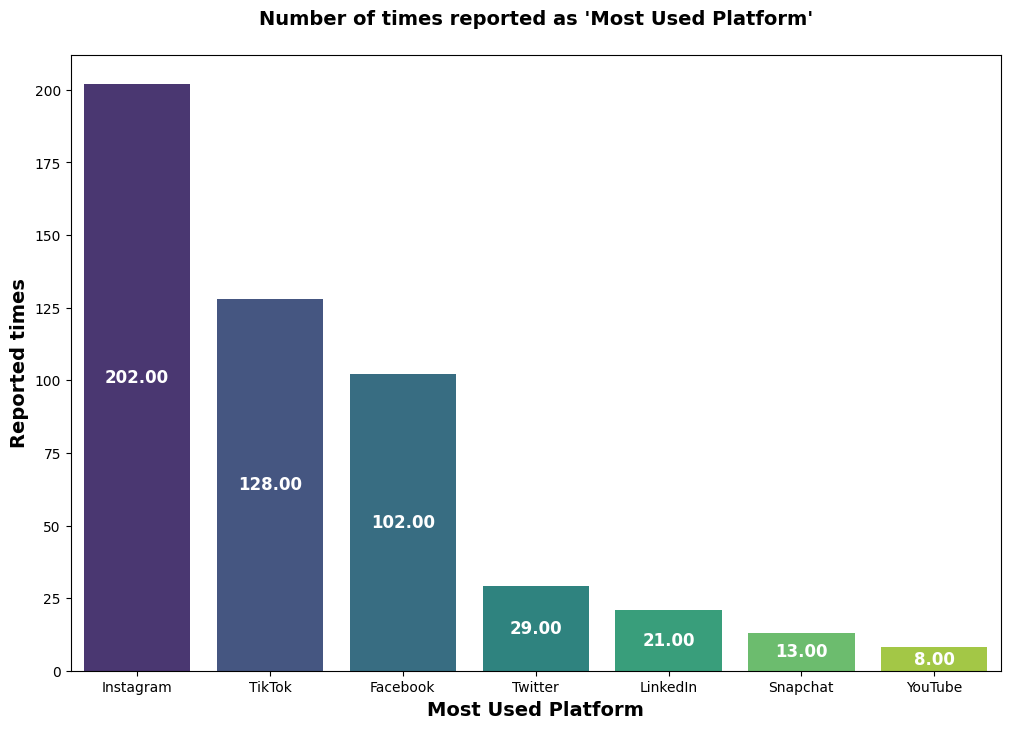

In [13]:
# Extraemos el gráfico a mostrar

plt.figure(figsize=(12, 8))

fig = sns.barplot(
    data=most_used_platform_count, 
    hue=most_used_platform_count["Most_Used_Platform"],
    x=most_used_platform_count["Most_Used_Platform"],
    y=most_used_platform_count["Count"],
    palette="viridis")

for p in fig.patches:
    # Get the height of the bar (the value on the y-axis)
    height = p.get_height()
    final_label = f'{height:.2f}'

    # Determine where to place the label:
    # x-coordinate: p.get_x() + p.get_width() / 2 (Center of the bar)
    # y-coordinate: height / 2 (Halfway up the bar, inside)

    # Add the text annotation
    fig.text(
        x=p.get_x() + p.get_width() / 2.,  # Center horizontally
        y=height * 0.5,                   # Place vertically at 50% height
        s=final_label,                     # The text to display
        ha='center',                      # Horizontal alignment
        va='center',                      # Vertical alignment
        color='white',                    # Use a contrasting color
        fontsize=12,
        fontweight='bold'
    )

fig.set_title("Number of times reported as 'Most Used Platform'" + "\n", fontweight='bold', fontsize=14);
fig.set_xlabel("Most Used Platform", fontweight='bold', fontsize=14);
fig.set_ylabel("Reported times", fontweight='bold', fontsize=14)
plt.show();

#### ✅ La sub-hipótesis 1 se verifica a la perfección 

Efectivamente, Instagram y Tik Tok son las plataformas que más veces han sido reportadas como la red social más utilizada

In [5]:
# Sub-hipótesis 2: Los usuarios que reportan como "Most_Used_Platform" las redes Instagram y Tik Tok, también reportan de media un mayor uso de redes sociales al día

mean_daily_usage_hours_grouped_by_most_used_platform = clean_data_df.groupby("Most_Used_Platform")['Avg_Daily_Usage_Hours'].mean().reset_index()
mean_daily_usage_hours_grouped_by_most_used_platform.columns = ["Most_Used_Platform", "Avg_Daily_Usage_Hours_of_ALL_social_media"]
mean_daily_usage_hours_grouped_by_most_used_platform = mean_daily_usage_hours_grouped_by_most_used_platform.sort_values(by="Avg_Daily_Usage_Hours_of_ALL_social_media", ascending=False)
mean_daily_usage_hours_grouped_by_most_used_platform


,Most_Used_Platform,Avg_Daily_Usage_Hours_of_ALL_social_media
4,TikTok,5.312500
3,Snapchat,5.092308
5,Twitter,4.965517
1,Instagram,4.807426
0,Facebook,4.388235
6,YouTube,4.162500
2,LinkedIn,2.519048


In [6]:
# Respecto al mayor dato de "Avg_Daily_Usage_Hours_of_ALL_social_media", vamos a revisar qué porcentaje de dicho valor representan el resto de filas:

top_usage_baseline = mean_daily_usage_hours_grouped_by_most_used_platform.iloc[[0]]["Avg_Daily_Usage_Hours_of_ALL_social_media"].item()

mean_daily_usage_hours_grouped_by_most_used_platform["Relative_to_TOP_usage_%"] = (mean_daily_usage_hours_grouped_by_most_used_platform["Avg_Daily_Usage_Hours_of_ALL_social_media"] / top_usage_baseline) * 100
mean_daily_usage_hours_grouped_by_most_used_platform

,Most_Used_Platform,Avg_Daily_Usage_Hours_of_ALL_social_media,Relative_to_TOP_usage_%
4,TikTok,5.312500,100.000000
3,Snapchat,5.092308,95.855204
5,Twitter,4.965517,93.468560
1,Instagram,4.807426,90.492720
0,Facebook,4.388235,82.602076
6,YouTube,4.162500,78.352941
2,LinkedIn,2.519048,47.417367


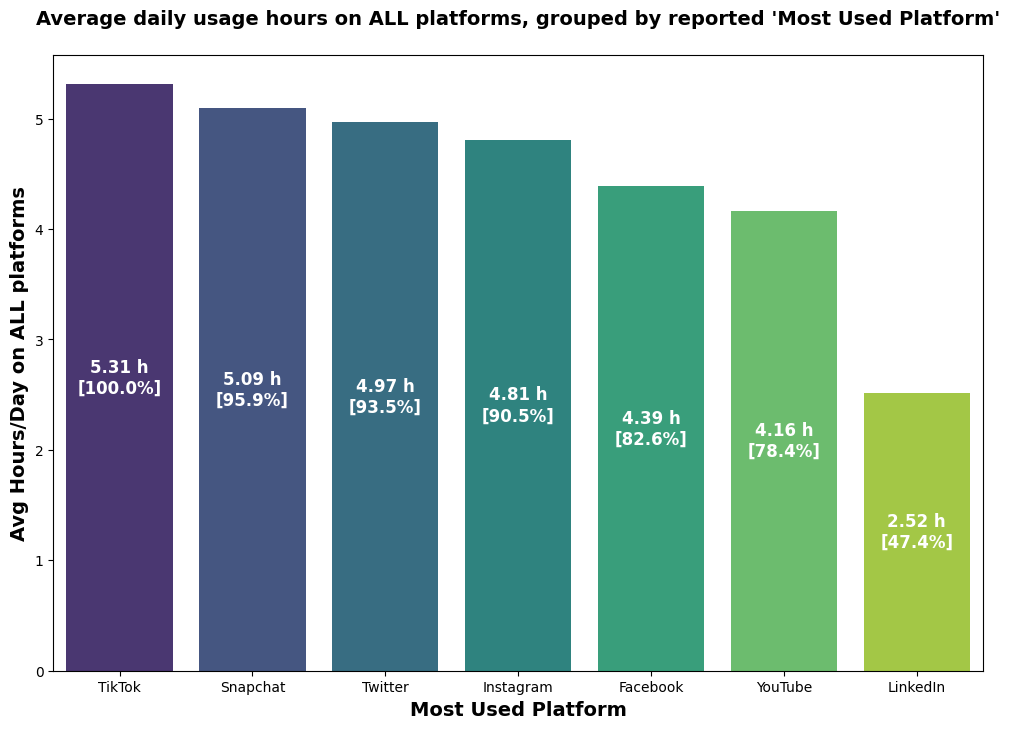

In [9]:
# Extraemos el gráfico a mostrar

plt.figure(figsize=(12, 8))

fig = sns.barplot(
    data=mean_daily_usage_hours_grouped_by_most_used_platform, 
    hue=mean_daily_usage_hours_grouped_by_most_used_platform["Most_Used_Platform"],
    x=mean_daily_usage_hours_grouped_by_most_used_platform["Most_Used_Platform"],
    y=mean_daily_usage_hours_grouped_by_most_used_platform["Avg_Daily_Usage_Hours_of_ALL_social_media"],
    palette="viridis")

for p in fig.patches:
    # Get the height of the bar (the value on the y-axis)
    height = p.get_height()

    x_category = fig.get_xticklabels()[fig.patches.index(p)].get_text() # Encuentra la Label del eje X, para poder buscar el porcentaje en el Dataframe

    # 2d. Lookup the specific Label_Text from the DataFrame
    label_percentage = mean_daily_usage_hours_grouped_by_most_used_platform[mean_daily_usage_hours_grouped_by_most_used_platform['Most_Used_Platform'] == x_category]['Relative_to_TOP_usage_%'].iloc[0]
    final_label = f'{height:.2f} h' + "\n" + f'[{label_percentage:.1f}%]' # Format the text (e.g., to 2 decimal places)
    # Determine where to place the label:
    # x-coordinate: p.get_x() + p.get_width() / 2 (Center of the bar)
    # y-coordinate: height / 2 (Halfway up the bar, inside)

    # Add the text annotation
    fig.text(
        x=p.get_x() + p.get_width() / 2.,  # Center horizontally
        y=height * 0.5,                   # Place vertically at 50% height
        s=final_label,                     # The text to display
        ha='center',                      # Horizontal alignment
        va='center',                      # Vertical alignment
        color='white',                    # Use a contrasting color
        fontsize=12,
        fontweight='bold'
    )

fig.set_title("Average daily usage hours on ALL platforms, grouped by reported 'Most Used Platform'" + "\n", fontweight='bold', fontsize=14);
fig.set_xlabel("Most Used Platform", fontweight='bold', fontsize=14);
fig.set_ylabel("Avg Hours/Day on ALL platforms", fontweight='bold', fontsize=14)
plt.show();


#### ❌ Debemos desmentir la Sub-hipótesis 2 

Según los resultados obtenidos, observamos que los usuarios que han reportado TikTok como "Most_Used_Platform" sí que lideran el uso medio de redes sociales. 

Sin embargo, esperábamos que "Instagram" también apareciera en el Top 2, y sin embargo aparece en la cuarta posición. En cualquier caso, cabe destacar que las diferencias de uso medio entre las posiciones 2, 3 y 4 no son demasiado significativas, a nivel relativo están entre el 90.49% y el 95.86% comparando con la agrupación con mayor uso, variando entre ellas menos del 3%

Esto nos lleva a **no poder validar categóricamente esta primera hipótesis**; nos lleva asimismo a tener que reescribir las hipótesis iniciales que estaban basadas en esta primera hipótesis